In [2]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Modelevaluation import SoilModel, HSdata_process
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
#from sklearn.model_selection import cross_val_score
import xgboost as xgb
import optuna
from optuna.visualization import plot_param_importances, plot_optimization_history
from matplotlib import rc

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 11
BIGGER_SIZE = 11

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["text.usetex"] = False
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')
plt.rc('text', usetex=False)
######################## Define the text size of each plot globally ###########

In [4]:
# =============================================================================
# Input structure HS - needs user interaction
# =============================================================================

input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi', 'psi', 
                'm', 'nu', 
                'Rf', 'CellPressure']
triaxial_column = ['q', 'eps_y', 
                   'eps_v', 'p']

odometer_column = ['sig_y', 'eps_y_oed']

In [5]:
# =============================================================================
# Input data - needs user interaction
# =============================================================================
degree_set = 7

data_in_y_dir_1 = 0 #number in triaxial_column
data_in_x_dir_1 = 3 #number in triaxial_column  

data_in_y_dir = triaxial_column[data_in_y_dir_1] 
data_in_x_dir = triaxial_column[data_in_x_dir_1] 
cell_pressure_set = [50,100,200,300,400]
cell_pressure_set = [50,100,200,300,400]
cell_pressure_set = [100]

In [6]:
# =============================================================================
# Modelevaluation HS
# ====================================================================

#input data for soil model
HS = HSdata_process(modelname='HardeninggSoil_Fel_new', 
                    CellPressure='CellPressure',
                    cellpressure_value=cell_pressure_set,
                    input_column= input_column,
                    triaxial_column = triaxial_column,
                    odoemeter_column= odometer_column)

input_parameters, output_triaxial, output_odometer = HS.data_processing()

def x_array(x_matrix):
    X_return = []
    for s in x_matrix:
        # Remove '[' and ']' characters, split by '\n' to get individual lines
        lines = s.strip('[]').split(',')
        values = []
        for line in lines:
            # Split each line by spaces, convert values to floats, and extend the list
            values.extend([float(val) for val in line.split()])   
        X_return.append(np.array(values))   
    X_return = np.array(X_return)
    return X_return

q = x_array(output_triaxial.iloc[:,0])
eps_y = x_array(output_triaxial.iloc[:,1])
eps_vol = x_array(output_triaxial.iloc[:,2])
p = x_array(output_triaxial.iloc[:,3])
sig_1 = x_array(output_odometer.iloc[:,0])
eps_y_oed = x_array(output_odometer.iloc[:,1])

In [7]:
print("Length of q:", q.shape[1])
print("Length of eps_y:", eps_y.shape[1])
print("Length of eps_vol:", eps_vol.shape[1])
print("Length of p:", p.shape[1])
print("Length of sig_1:", sig_1.shape[1])
print("Length of eps_y_oed:", eps_y_oed.shape[1])

Length of q: 251
Length of eps_y: 251
Length of eps_vol: 251
Length of p: 251
Length of sig_1: 201
Length of eps_y_oed: 201


In [8]:
X = np.hstack((q, eps_y, eps_vol, eps_y, q, p, sig_1, eps_y_oed))
X = np.hstack((q, eps_vol, q, p, sig_1))
y = input_parameters

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
def objective(trial):
    param = {
        "objective": "reg:squarederror",
        'n_estimators': trial.suggest_int('n_estimators', 80, 150),
        'tree_method': 'hist',
        "verbosity": 1,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
    }

    model = xgb.XGBRegressor(**param, random_state=42, n_jobs=-1, early_stopping_rounds=5)
    model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_eval,y_eval)], verbose=False)
    y_pred = model.predict(X_eval)
    r2 = r2_score(y_true = y_eval, y_pred = y_pred)
    return r2

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)


best_params = {
    'objective': 'reg:squarederror',
    'n_estimators': 128,
    'tree_method': 'hist',
    "verbosity": 1,
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.7,
    'n_jobs': -1,
    'random_state': 42,
}

# Update with the best hyperparameters
best_params.update(study.best_params)

# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params)

# Train the final model with the best hyperparameters
final_model.fit(X_train, y_train)

[I 2024-03-08 18:56:25,406] A new study created in memory with name: no-name-065e5fa4-9718-4957-a093-580bfbd7b204
[I 2024-03-08 18:57:20,066] Trial 0 finished with value: -689350671.0179304 and parameters: {'n_estimators': 146, 'learning_rate': 0.013539943676238474, 'max_depth': 1, 'subsample': 0.971884426714893}. Best is trial 0 with value: -689350671.0179304.
[I 2024-03-08 19:02:45,266] Trial 1 finished with value: -3252851783.689021 and parameters: {'n_estimators': 149, 'learning_rate': 0.008119661614213085, 'max_depth': 11, 'subsample': 0.3161896685444509}. Best is trial 0 with value: -689350671.0179304.
[I 2024-03-08 19:03:43,808] Trial 2 finished with value: 0.7457644207190571 and parameters: {'n_estimators': 127, 'learning_rate': 0.10319905542596182, 'max_depth': 2, 'subsample': 0.2262384336623905}. Best is trial 2 with value: 0.7457644207190571.
[I 2024-03-08 19:05:10,521] Trial 3 finished with value: -1433701151.9193544 and parameters: {'n_estimators': 138, 'learning_rate': 0.

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.265715672438129,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=99, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [11]:
# Plot optimization history
plot_optimization_history(study)

In [12]:
# Plot parameter importances
plot_param_importances(study)

In [1]:
input_column_label = ['$E_{50}^{ref}$', '$E_{oed}^{ref}$', '$E_{ur}^{ref}$', 
                r"$\varphi$'", '$\psi$', 
                '${m}$', '${ν}$', 
                '${R_f}$', '$CellPressure$']


cm = 1/2.54  # centimeters in inches
print('-----------Test Data----------')
# check performance on test data
y_pred = final_model.predict(X_test)
for i in range(y_pred.shape[1]-1):
    y_true_col = y_test.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.3f}')
    # Change the figsize
    plt.gcf().set_figwidth(5.333333333*cm)
    plt.gcf().set_figheight(5.333333333*cm)
    plt.xticks(rotation=45)
    #plt.tight_layout()
    plt.subplots_adjust(left=0.32, right=0.95, bottom=0.3, top=0.90)
    plt.savefig(f'..\graphics\{i}_{input_column[i]}_test_data.png', dpi = 500)

-----------Test Data----------


NameError: name 'final_model' is not defined

In [25]:
# check performance on test data

y_pred = final_model.predict(X_test)
y_pred_crop = y_pred[:, :-1]
y_test_crop = y_test.iloc[:, :-1]


score, mse = HS.eval_error(y_true = y_test_crop, y_pred=y_pred_crop)
print(f'R2 Error test data: {round(score, 3)}, Test MSE: {round(mse, 3)}')


R2 Error test data: 0.989, Test MSE: 11431590.601


-----------Training Data----------


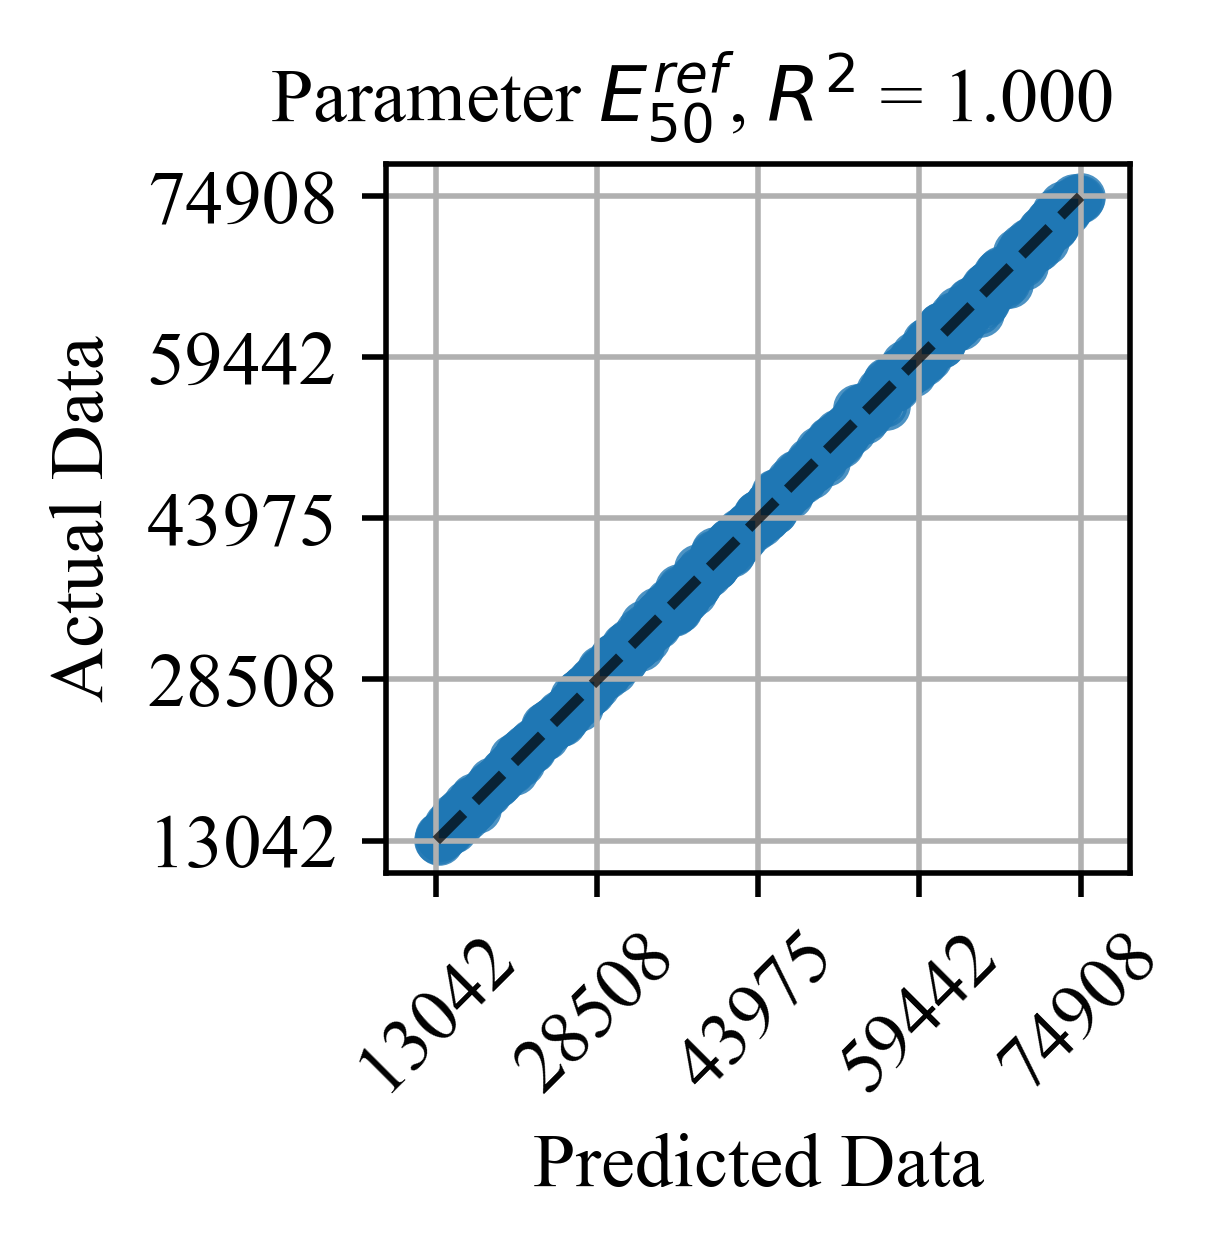

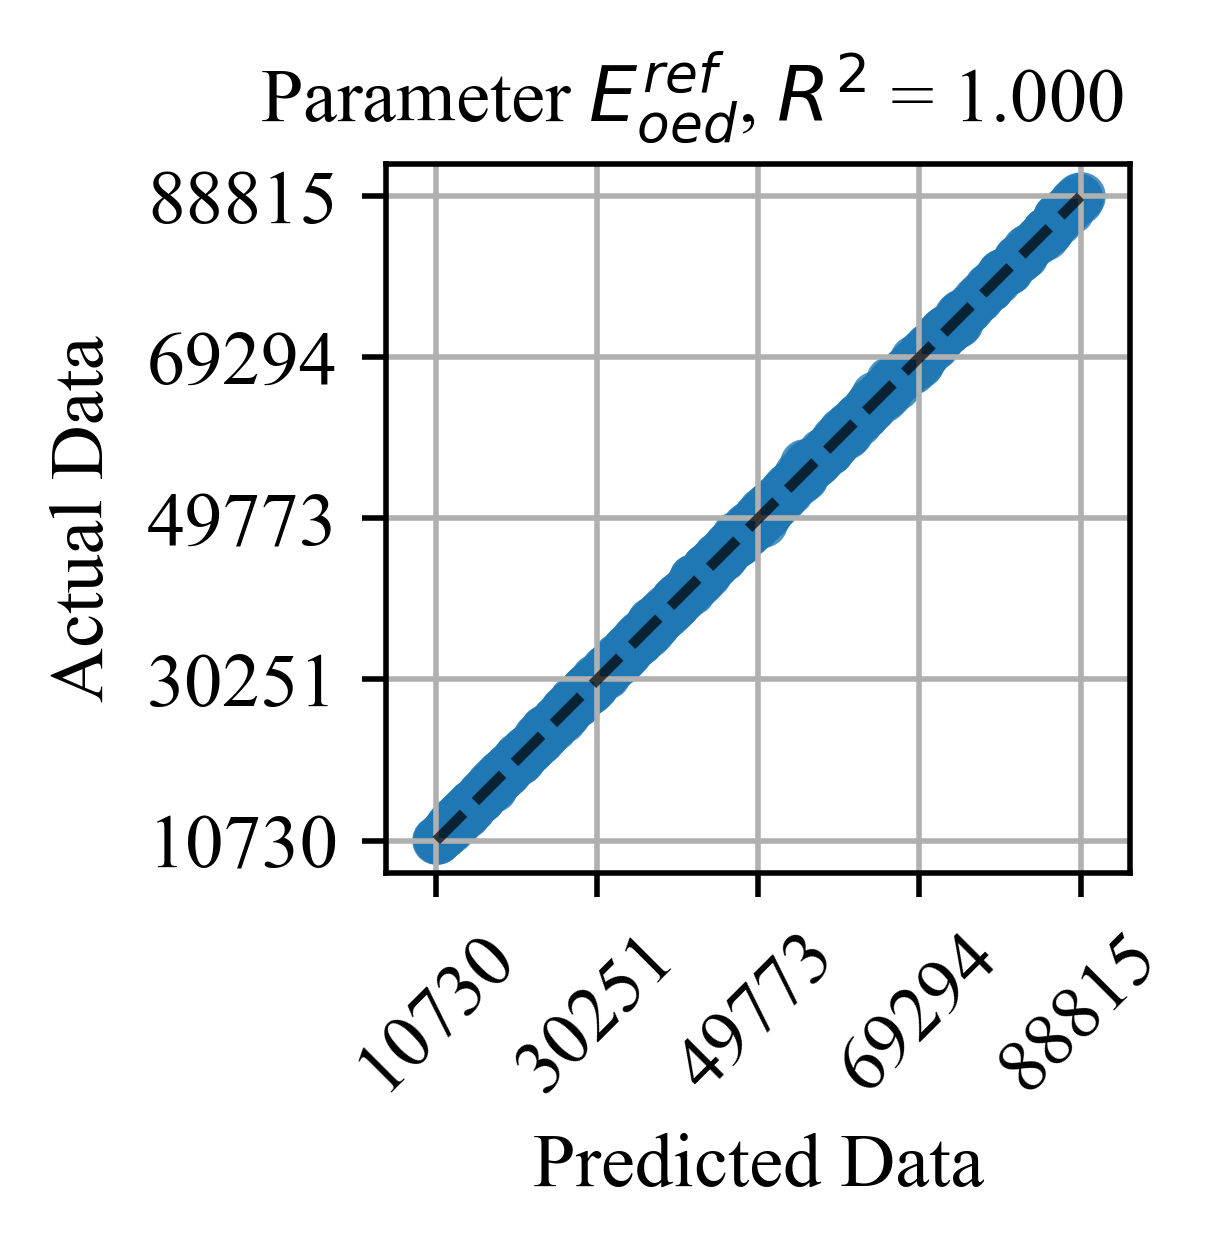

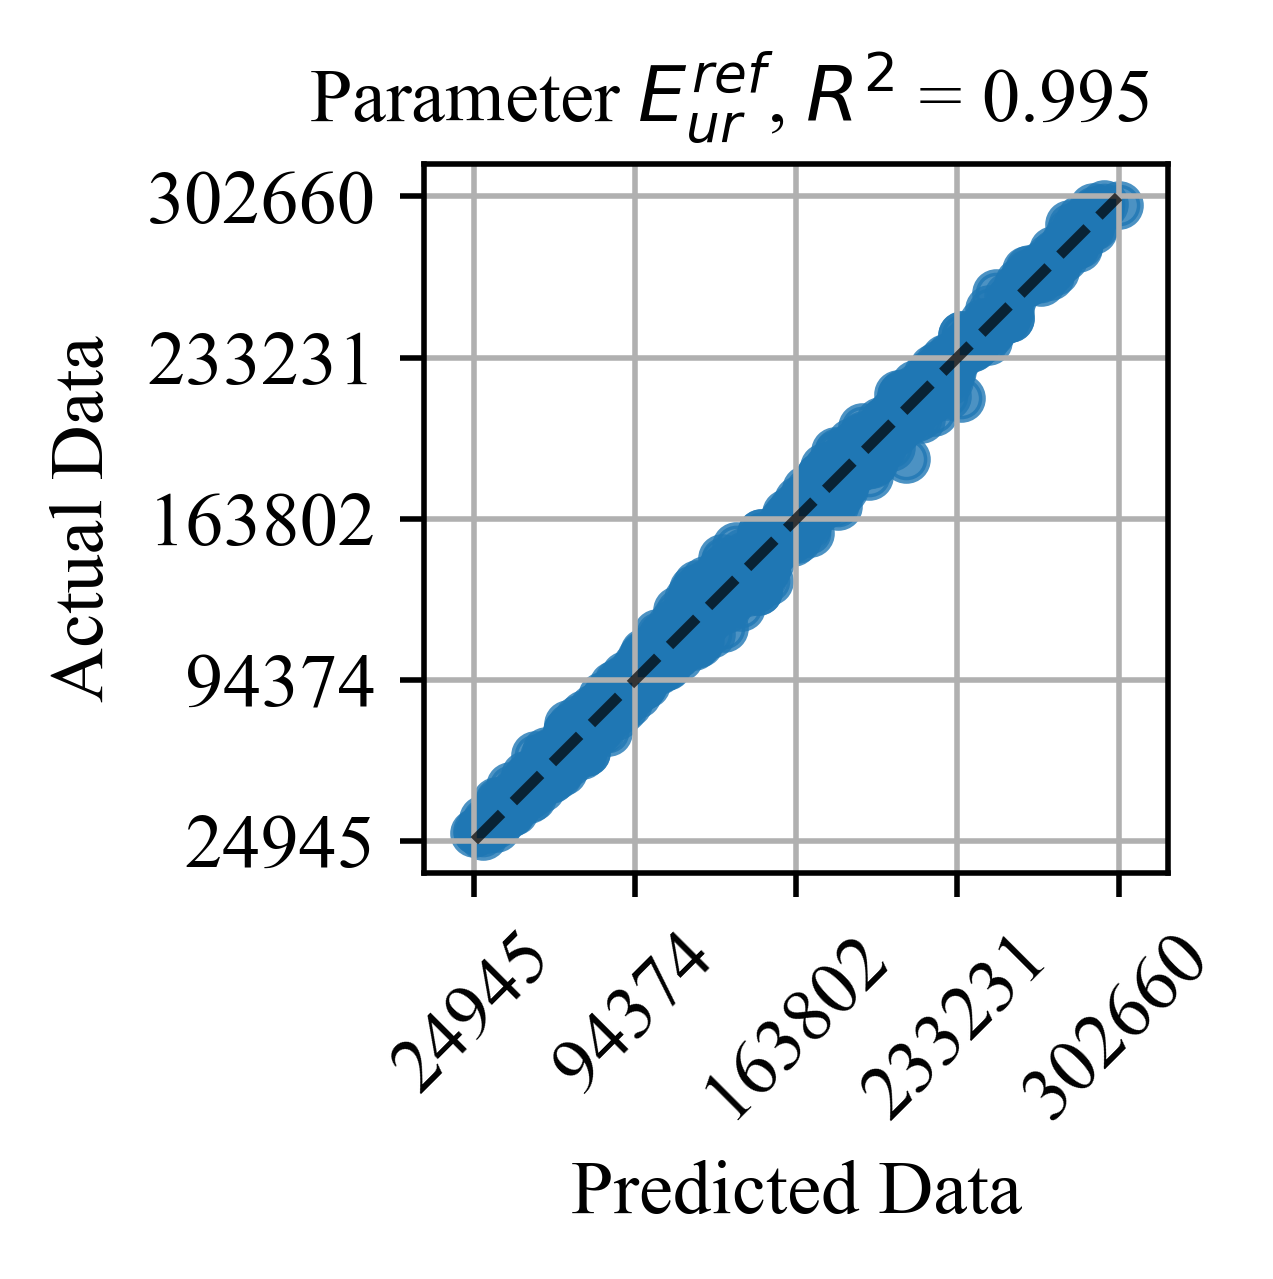

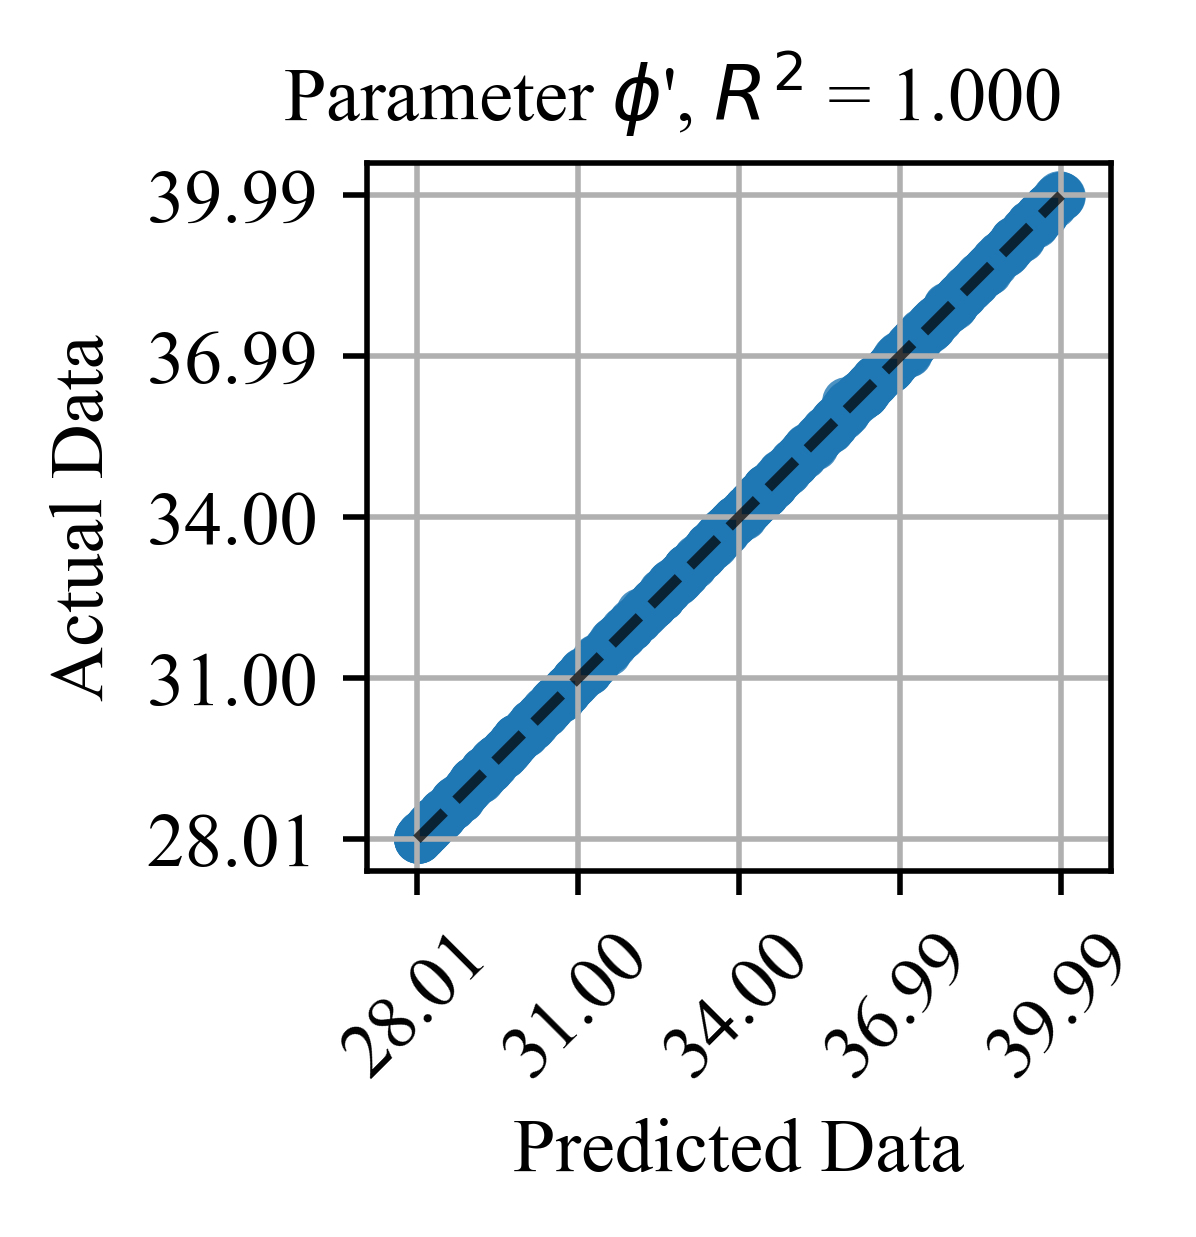

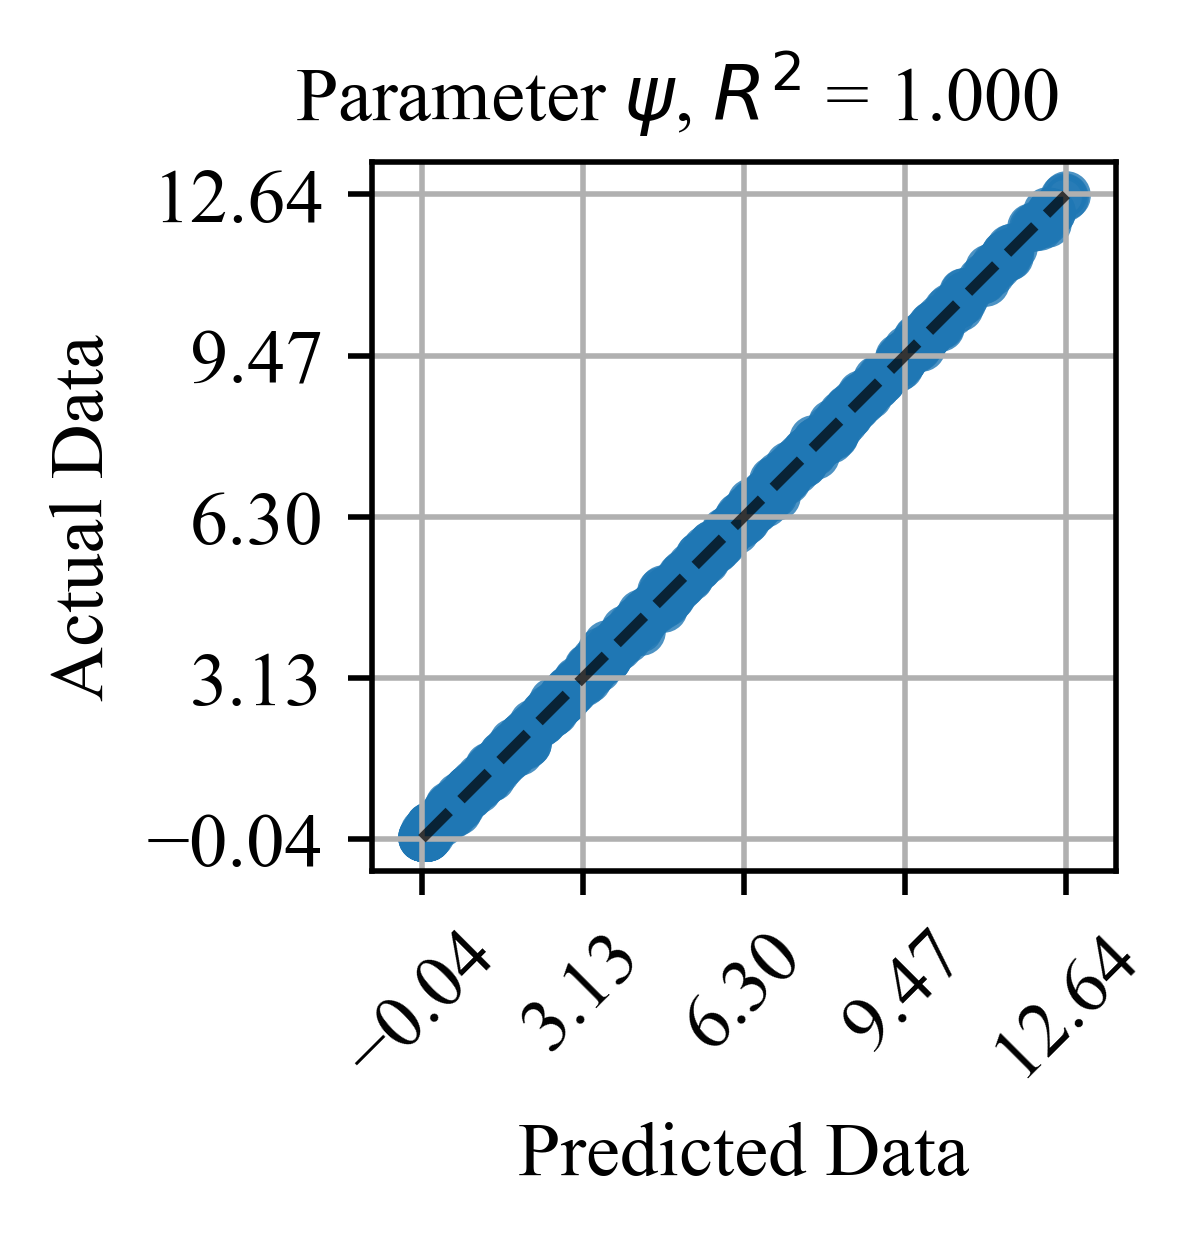

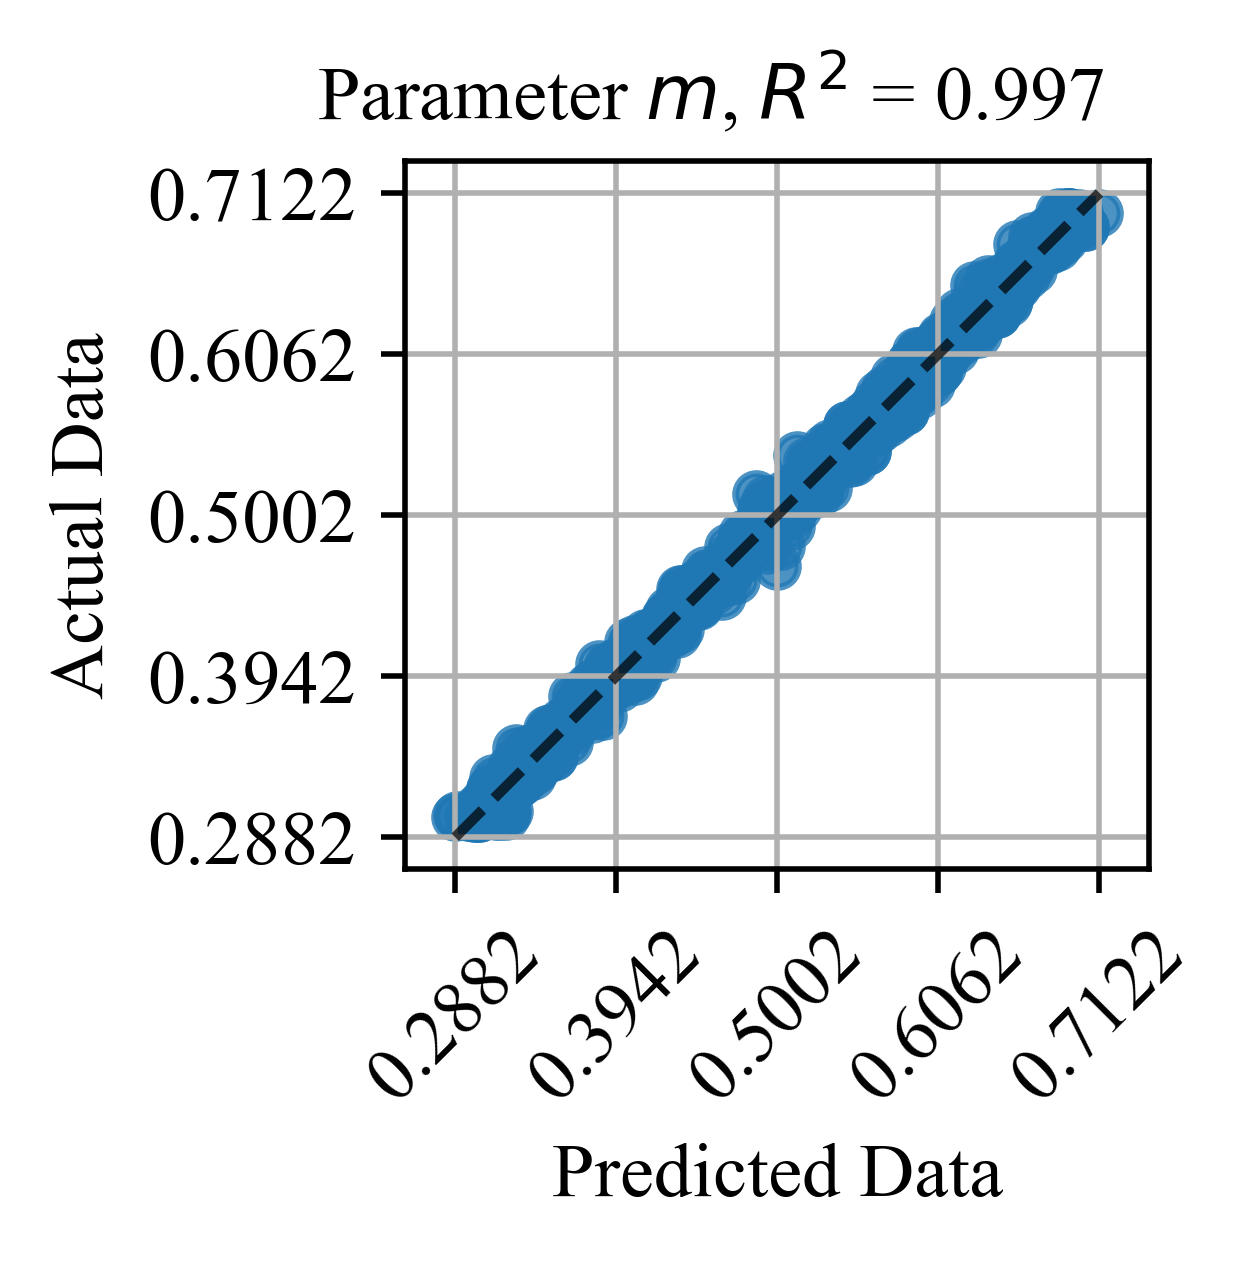

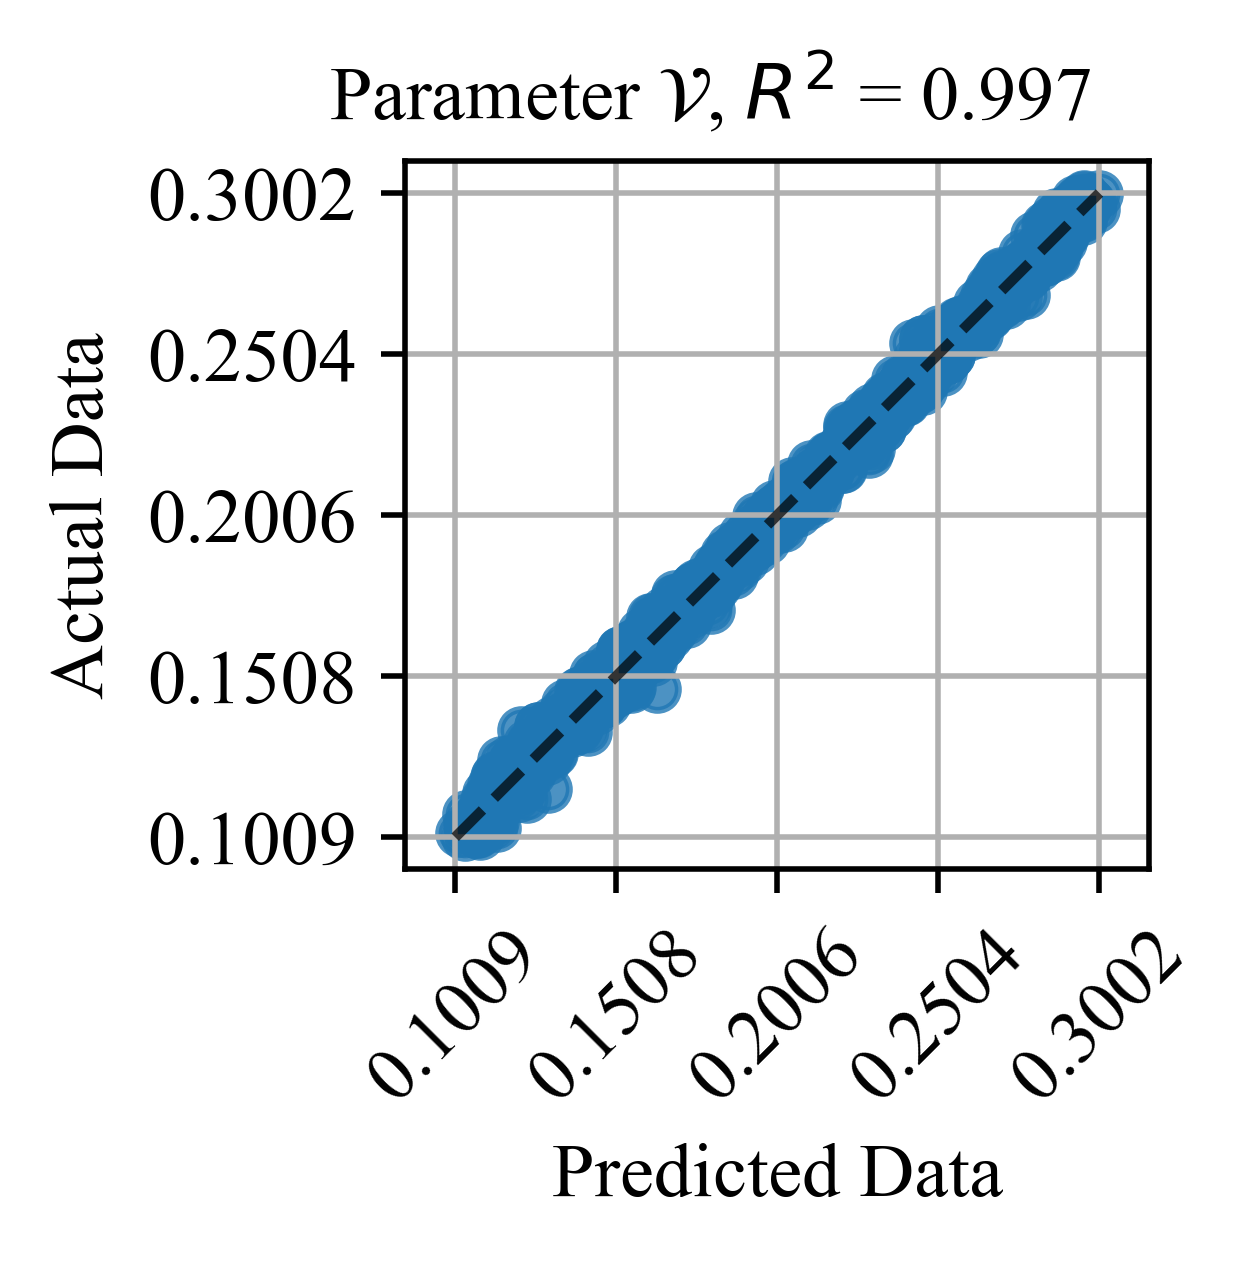

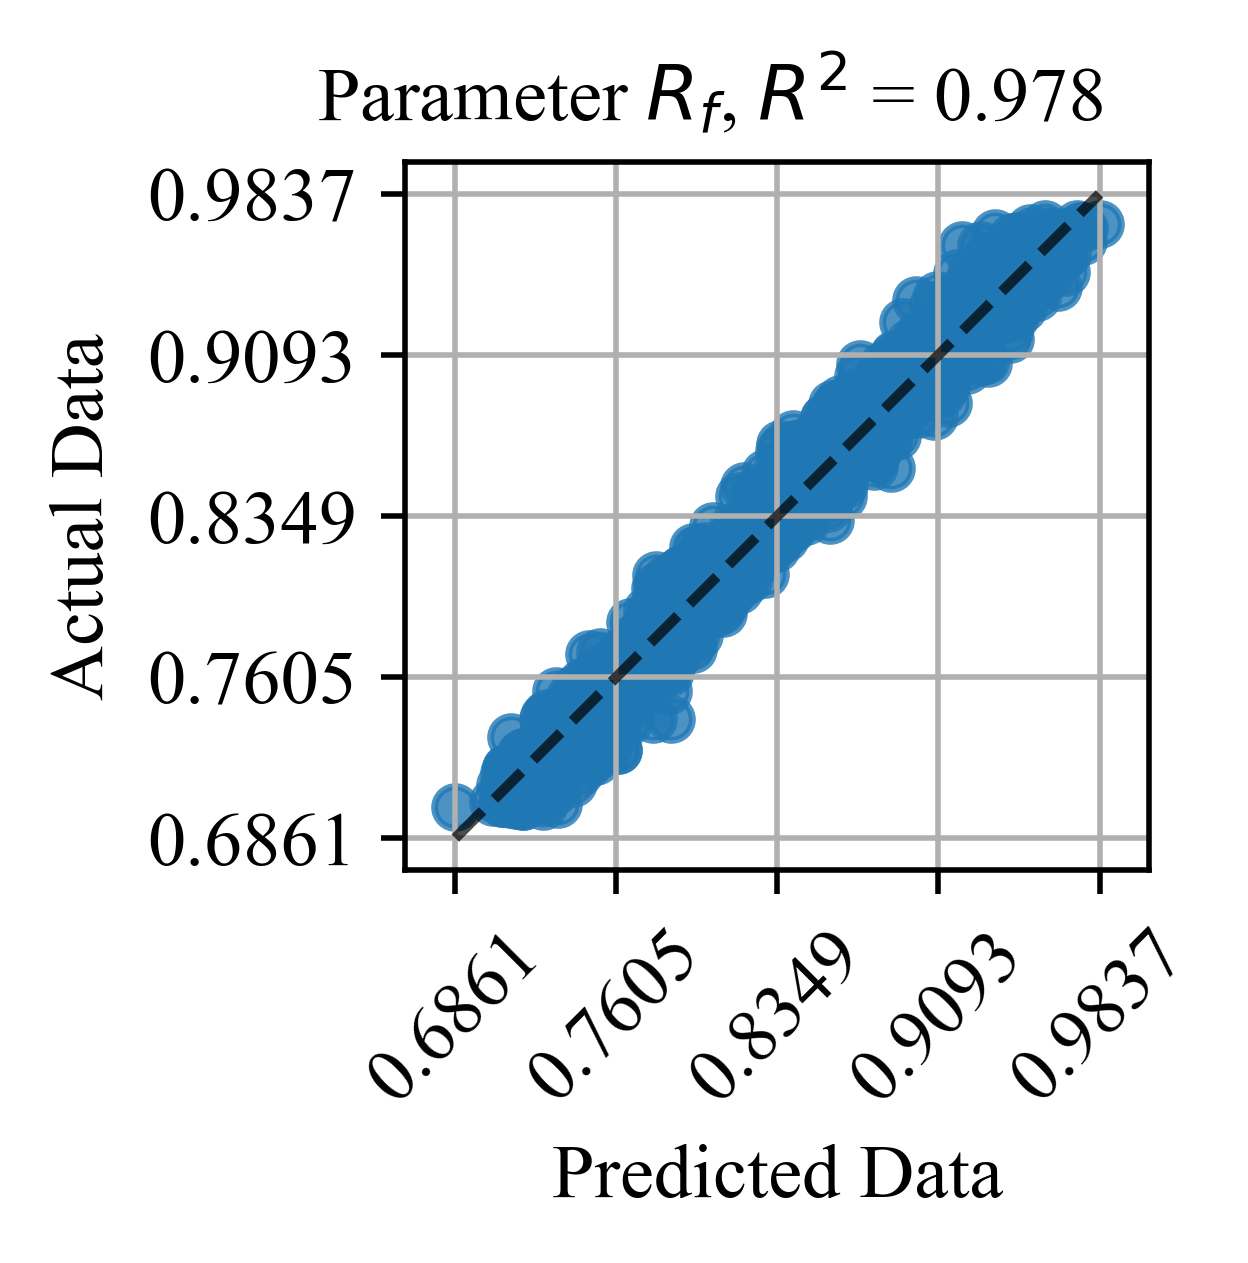

In [26]:
cm = 1/2.54  # centimeters in inches
print('-----------Training Data----------')
# check performance on test data
y_pred = final_model.predict(X_train)
for i in range(y_pred.shape[1]-1):
    y_true_col = y_train.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.3f}')
    # Change the figsize
    plt.gcf().set_figwidth(6*cm)
    plt.gcf().set_figheight(6*cm)
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.32, right=0.95, bottom=0.3, top=0.90)
    plt.savefig(f'..\graphics\{i+10}_{input_column[i]}_train_data.png', dpi = 500)

In [10]:
best_params = {
    'objective': 'reg:squarederror',
    'n_estimators': 128,
    'tree_method': 'hist',
    "verbosity": 1,
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.7,
    'n_jobs': -1,
    'random_state': 42,
}

# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X, y)
final_model.save_model("HS_model_xgb_adopted.bin")

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\xgboost\core.py:160: UserWarning: [20:56:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
